In [3]:
import xarray as xr
import numpy as np
import pickle
from matplotlib import pyplot as plt
from src.processing import clustering
import geopandas as gpd
import cftime
from shapely.geometry import box
import nctoolkit


In [5]:
shape = gpd.read_file("./data/ne_110m_land/ne_110m_land.shp")

ds_47 = xr.open_dataset("./results/47/snow_47.nc")

In [11]:
lats = [-90.      , -88.105263, -86.210526, -84.315789, -82.421053, -80.526316,
       -78.631579, -76.736842, -74.842105, -72.947368, -71.052632, -69.157895,
       -67.263158, -65.368421, -63.473684, -61.578947, -59.684211, -57.789474,
       -55.894737, -54.      , -52.105263, -50.210526, -48.315789, -46.421053,
       -44.526316, -42.631579, -40.736842, -38.842105, -36.947368, -35.052632,
       -33.157895, -31.263158, -29.368421, -27.473684, -25.578947, -23.684211,
       -21.789474, -19.894737, -18.      , -16.105263, -14.210526, -12.315789,
       -10.421053,  -8.526316,  -6.631579,  -4.736842,  -2.842105,  -0.947368,
         0.947368,   2.842105,   4.736842,   6.631579,   8.526316,  10.421053,
        12.315789,  14.210526,  16.105263,  18.      ,  19.894737,  21.789474,
        23.684211,  25.578947,  27.473684,  29.368421,  31.263158,  33.157895,
        35.052632,  36.947368,  38.842105,  40.736842,  42.631579,  44.526316,
        46.421053,  48.315789,  50.210526,  52.105263,  54.      ,  55.894737,
        57.789474,  59.684211,  61.578947,  63.473684,  65.368421,  67.263158,
        69.157895,  71.052632,  72.947368,  74.842105,  76.736842,  78.631579,
        80.526316,  82.421053,  84.315789,  86.210526,  88.105263,  90.      ]

In [11]:
from src.preprocessing.prepare_data import load_climate_files

In [12]:
ds = load_climate_files("./data/Model_Output_From_Harrison/Temp_Precip/nw_targets_05", "nw_targets_05.cam.h0.*.nc",)

Found: 180 files
First file: nw_targets_05.cam.h0.0005-01.nc
Last file: nw_targets_05.cam.h0.0019-12.nc


In [18]:
ds

<xarray.Dataset>
Dimensions:    (time: 180, lat: 96, lon: 144, nbnd: 2)
Coordinates:
  * lat        (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon        (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) object 0005-02-01 00:00:00 ... 0020-01-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    PRECC      (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    PRECL      (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    TS         (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    TSMN       (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    TSMX       (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    time_bnds  (time, nbnd) object dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    Conventions:      CF-1.0
    source:           CAM
    case:             nw_targets_05
    title:            UNSET
    logname:          bardeenc
    host:             shas0131
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /projects/bardeenc/inputdata/f2000.e10r02.2deg.waccm.00...
    topography_file:  /gpfs/summit/datasets/CESM/inputdata/atm/cam/topo/consi...
    history:          Mon Oct 21 08:27:38 2024: ncks -v TS,TSMN,TSMX,PRECC,PR...
    NCO:              netCDF Operators version 5.1.4 (Homepage = http://nco.s...

In [6]:
from snow_analysis import compute_cell_area,compute_grid_cell_area

In [7]:
cosinus = compute_cell_area(ds_47.snow_storage)
sinus = compute_grid_cell_area(ds_47.snow_storage)

In [ ]:
print(sinus.sum().values, cosinus.sum().values)

510064471.9097875 510017987.8256377


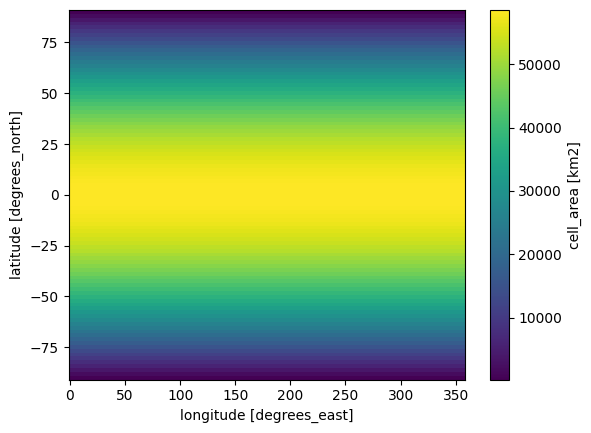

In [27]:
sinus.plot()

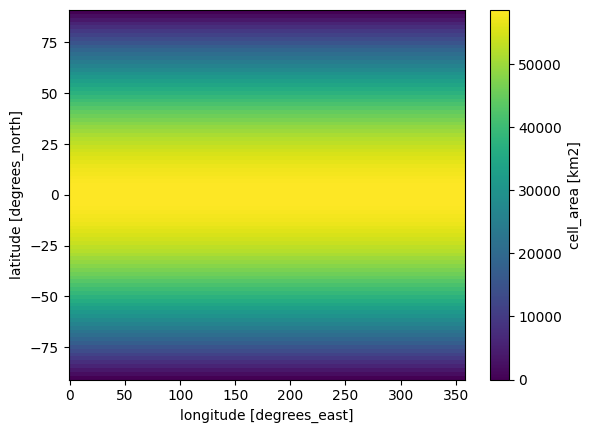

In [28]:
cosinus.plot()

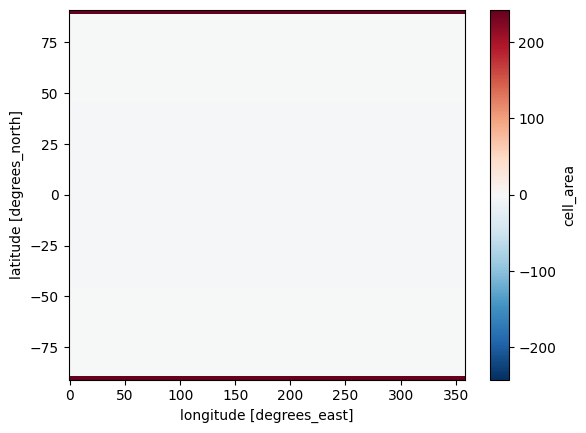

In [6]:
(sinus - cosinus).plot()

In [9]:
da = ds_47.snow_storage

In [11]:
ds_47.cell_area()

AttributeError: 'Dataset' object has no attribute 'cell_area'

In [18]:
def compute_land_fractions(da, shape):
    """
    Berechnet den Landanteil jeder Rasterzelle.
    
    Parameter
    ----------
    da : xarray.DataArray
        Muss lat- und lon-Koordinaten besitzen (lon 0–360).
    shape : geopandas.GeoDataFrame
        Shapefile mit Landpolygonen (lon -180 bis 180).
    
    Returns
    -------
    fractions : xarray.DataArray
        2D DataArray (lat, lon) mit Landanteilen zwischen 0 und 1.
    """
    shape_union = shape.union_all()
    
    fractions = np.zeros((len(da.lat), len(da.lon)))
    dlat = float(abs(da.lat[1] - da.lat[0])) / 2
    dlon = float(abs(da.lon[1] - da.lon[0])) / 2

    for i, lat in enumerate(da.lat.values):
        for j, lon in enumerate(da.lon.values):
            
            # Lon von 0–360 auf -180–180 umrechnen
            lon_centered = lon if lon <= 180 else lon - 360

            # Zellgrenzen berechnen und Pole clippen
            lat_lower = max(lat - dlat, -90)
            lat_upper = min(lat + dlat,  90)
            lon_left  = lon_centered - dlon
            lon_right = lon_centered + dlon

            cell = box(lon_left, lat_lower, lon_right, lat_upper)
            intersection = shape_union.intersection(cell)
            fractions[i, j] = intersection.area / cell.area

    return xr.DataArray(
        fractions,
        coords={"lat": da.lat, "lon": da.lon},
        dims=["lat", "lon"],
        attrs={"long_name": "Land fraction", "units": "1"},
    )

In [21]:
result = compute_land_fractions(da, shape)

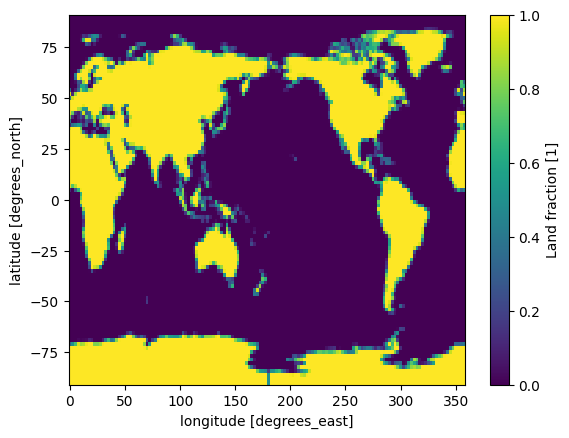

In [22]:
result.plot()

In [ ]:
def compute_land_fractions(da, shape):
    """
    Berechnet den Landanteil jeder Rasterzelle.
    Parameter
    ----------
    da : xarray.DataArray
        Muss lat- und lon-Koordinaten besitzen (lon 0–360).
    shape : geopandas.GeoDataFrame
        Shapefile mit Landpolygonen (lon -180 bis 180).
    Returns
    -------
    fractions : xarray.DataArray
        2D DataArray (lat, lon) mit Landanteilen zwischen 0 und 1.
    """
    # Alle Landpolygone zu einem einzigen Polygon zusammenführen
    # → vermeidet mehrfache Verschneidungen pro Zelle
    shape_union = shape.union_all()

    # Ergebnisarray initialisieren (alle Werte = 0)
    fractions = np.zeros((len(da.lat), len(da.lon)))

    # Halbe Zellgröße in jede Richtung berechnen
    # → wird benötigt um die Zellgrenzen um den Mittelpunkt zu berechnen
    dlat = float(abs(da.lat[1] - da.lat[0])) / 2
    dlon = float(abs(da.lon[1] - da.lon[0])) / 2

    for i, lat in enumerate(da.lat.values):
        for j, lon in enumerate(da.lon.values):

            # Lon von 0–360 auf -180–180 umrechnen damit es zum
            # Koordinatensystem des Shapefiles passt
            # Beispiel: 270° → -90°,  180° bleibt 180°
            lon_centered = lon if lon <= 180 else lon - 360

            # Zellgrenzen in Lat-Richtung berechnen und auf ±90° clippen
            # → verhindert dass Polzellen über den Pol hinausragen
            lat_lower = max(lat - dlat, -90)
            lat_upper = min(lat + dlat,  90)

            # Zellgrenzen in Lon-Richtung berechnen
            lon_left  = lon_centered - dlon
            lon_right = lon_centered + dlon

            # Sonderfall: Zelle überschreitet den Antimeridian (180°) nach rechts
            # → Zelle wird in zwei Hälften aufgeteilt: rechts von 180° wird
            #    auf die linke Seite der Karte gespiegelt (-180° bis lon_right-360°)
            if lon_right > 180:
                cell_left  = box(lon_left, lat_lower, 180,            lat_upper)
                cell_right = box(-180,     lat_lower, lon_right - 360, lat_upper)
                intersection = (shape_union.intersection(cell_left).area +
                                shape_union.intersection(cell_right).area)
                cell_area = cell_left.area + cell_right.area

            # Sonderfall: Zelle überschreitet den Antimeridian (-180°) nach links
            # → analog: linke Hälfte wird auf die rechte Seite gespiegelt
            elif lon_left < -180:
                cell_left  = box(lon_left + 360, lat_lower, 180,      lat_upper)
                cell_right = box(-180,            lat_lower, lon_right, lat_upper)
                intersection = (shape_union.intersection(cell_left).area +
                                shape_union.intersection(cell_right).area)
                cell_area = cell_left.area + cell_right.area

            # Normalfall: Zelle liegt vollständig innerhalb von ±180°
            else:
                cell = box(lon_left, lat_lower, lon_right, lat_upper)
                intersection = shape_union.intersection(cell).area
                cell_area = cell.area

            # Landanteil = Schnittfläche mit Landpolygon / Gesamtfläche der Zelle
            fractions[i, j] = intersection / cell_area

    # Als xarray DataArray zurückgeben mit denselben Koordinaten wie Eingangsarray
    return xr.DataArray(
        fractions,
        coords={"lat": da.lat, "lon": da.lon},
        dims=["lat", "lon"],
        attrs={"long_name": "Land fraction", "units": "1"},
    )

In [24]:
result = compute_land_fractions(da, shape)

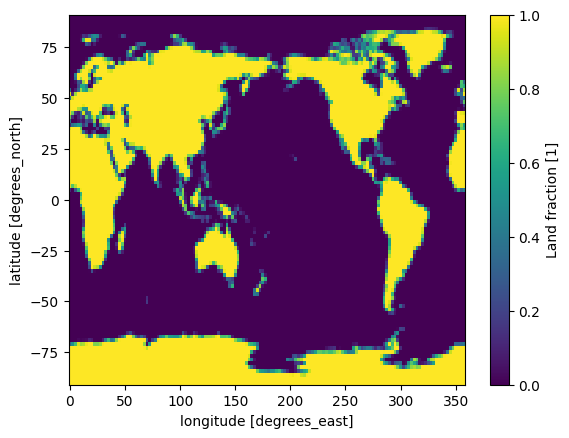

In [25]:
result.plot()

In [33]:
mask_alt = xr.open_dataset("./data/interim/land_mask_alt.nc")

In [4]:
regionmask_neu = xr.open_dataset("./results/47/land_mask_regionmask.nc")

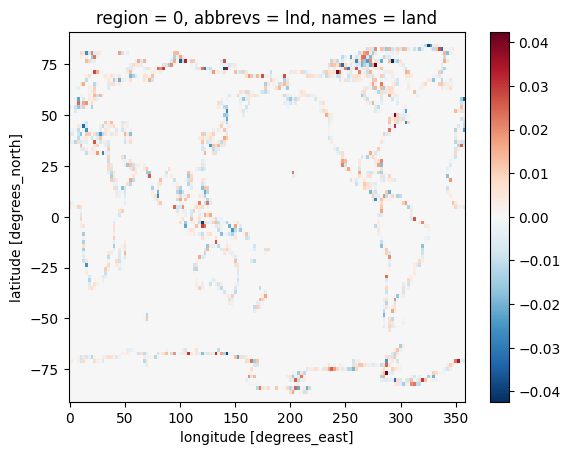

In [26]:
(regionmask_neu.mask-result).plot()

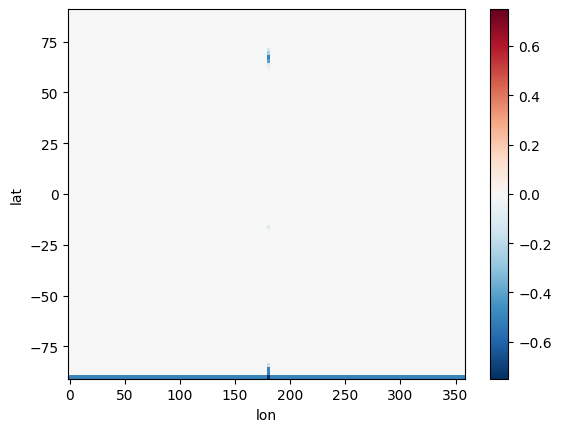

In [36]:
(mask_alt.land_mask - result).plot()

In [7]:
import xarray as xr
import geopandas as gpd


area_xr, fraction_xr = compute_land_fraction(ds_47, shape)

/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/.venv/lib/python3.11/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/.venv/lib/python3.11/site-packages/shapely/measurement.py:50: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)


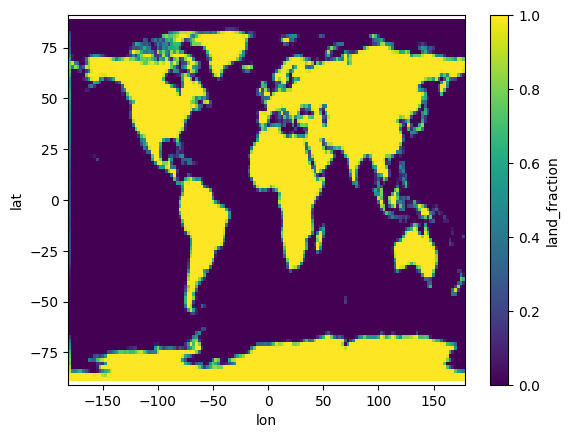

In [9]:
fraction_xr.plot()

In [10]:
import numpy as np
import xarray as xr

def calculate_cell_areas(ds: xr.Dataset | xr.DataArray,
                          lat_name: str = "lat",
                          lon_name: str = "lon",
                          cyclic_lon: bool = True) -> xr.DataArray:
    """
    Berechnet die Fläche jeder Gitterzelle in einem xarray mit lat/lon-Dimensionen.

    Parameters
    ----------
    ds : xr.Dataset | xr.DataArray
        Eingabe-Dataset oder DataArray mit lat/lon-Koordinaten.
    lat_name : str
        Name der Breitengrad-Dimension (default: "lat").
    lon_name : str
        Name der Längengrad-Dimension (default: "lon").
    cyclic_lon : bool
        True (default): Längengrad-Gitter ist global/zyklisch (0–360° oder -180–180°).
        Der letzte Zellenrand wird als coords[0] + 360° gesetzt.
        False: Randextrapolation wie bei Breitengraden (z.B. regionale Ausschnitte).

    Returns
    -------
    xr.DataArray
        Fläche jeder Gitterzelle in Quadratkilometern [km²].
    """
    R = 6371.0  # Erdradius in km

    lats = ds[lat_name].values
    lons = ds[lon_name].values

    def cell_bounds_lat(coords: np.ndarray) -> np.ndarray:
        mid = 0.5 * (coords[:-1] + coords[1:])
        left  = coords[0]  - (mid[0]  - coords[0])
        right = coords[-1] + (coords[-1] - mid[-1])
        # Auf [-90, 90] clippen
        return np.clip(np.concatenate([[left], mid, [right]]), -90, 90)

    def cell_bounds_lon(coords: np.ndarray, cyclic: bool) -> np.ndarray:
        mid = 0.5 * (coords[:-1] + coords[1:])
        left = coords[0] - (mid[0] - coords[0])
        if cyclic:
            right = coords[0] + 360.0  # Wrap-around
        else:
            right = coords[-1] + (coords[-1] - mid[-1])
        return np.concatenate([[left], mid, [right]])

    lat_bounds = cell_bounds_lat(lats)
    lon_bounds = cell_bounds_lon(lons, cyclic=cyclic_lon)

    d_lon_rad  = np.abs(np.diff(np.deg2rad(lon_bounds)))
    d_sin_lat  = np.abs(np.diff(np.sin(np.deg2rad(lat_bounds))))

    area = R**2 * d_sin_lat[:, np.newaxis] * d_lon_rad[np.newaxis, :]

    return xr.DataArray(
        area,
        coords={lat_name: ds[lat_name], lon_name: ds[lon_name]},
        dims=[lat_name, lon_name],
        attrs={"units": "km²", "long_name": "Grid cell area"},
    )

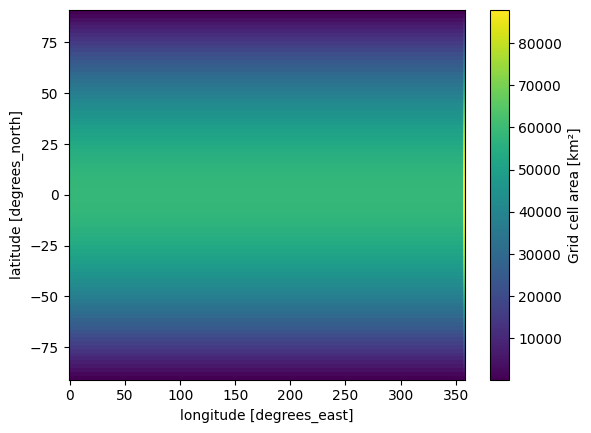

In [14]:
calculate_cell_areas(ds_47).plot()

In [16]:
ds_47.attrs

{'Conventions': 'CF-1.0',
 'source': 'CAM',
 'case': 'nw_targets_05',
 'title': 'UNSET',
 'logname': 'bardeenc',
 'host': 'shas0131',
 'Version': '$Name$',
 'revision_Id': '$Id$',
 'initial_file': '/projects/bardeenc/inputdata/f2000.e10r02.2deg.waccm.005.landfrac.cam2.i.0017-01-01-00000.nc',
 'topography_file': '/gpfs/summit/datasets/CESM/inputdata/atm/cam/topo/consistent-topo-fv1.9x2.5_c130424.nc',
 'history': 'Mon Oct 21 08:27:38 2024: ncks -v TS,TSMN,TSMX,PRECC,PRECL /pl/archive/toon_opp_impacts/waccm4/nw_targets_05/atm/hist/nw_targets_05.cam.h0.0005-01.nc /scratch/alpine/joco6825/dwinstead_data/nw_targets_05/nw_targets_05.cam.h0.0005-01.nc',
 'NCO': 'netCDF Operators version 5.1.4 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}